# Phase 01 EDA — Translated Gold (Branch B)

In [1]:
import sys
from pathlib import Path
_p = Path.cwd()
ROOT = next((c for c in [_p, *_p.parents] if (c / "src").is_dir() and (c / "data").is_dir()), _p)
for d in (str(ROOT), str(ROOT / "notebooks")):
    if d not in sys.path:
        sys.path.insert(0, d)
from _eda_style import setup, savefig
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
ROOT, FIG_DIR = setup()
print("repo root:", ROOT)

repo root: D:\esg-washing


## 0. Load all gold tasks

In [2]:
TASKS = ["env", "soc", "gov", "commitment", "specificity"]
SPLITS = ["train", "val", "test"]
gold = {t: {sp: pd.read_parquet(ROOT / f"data/vi_gold/{t}/{sp}.parquet") for sp in SPLITS} for t in TASKS}
for t in TASKS:
    n = {sp: len(gold[t][sp]) for sp in SPLITS}
    print(f"{t:12} {n}  train pos-rate={gold[t]['train']['label'].mean():.3f}")

env          {'train': 1568, 'val': 196, 'test': 196}  train pos-rate=0.325
soc          {'train': 1590, 'val': 199, 'test': 199}  train pos-rate=0.399
gov          {'train': 1576, 'val': 198, 'test': 198}  train pos-rate=0.268
commitment   {'train': 841, 'val': 149, 'test': 320}  train pos-rate=0.422
specificity  {'train': 841, 'val': 149, 'test': 320}  train pos-rate=0.400


## 1. Label balance per task & split (stratification check)
Positive rate should stay ~constant across train/val/test if stratification worked.

saved -> figures/phase01/gold_label_balance.png (+pdf)


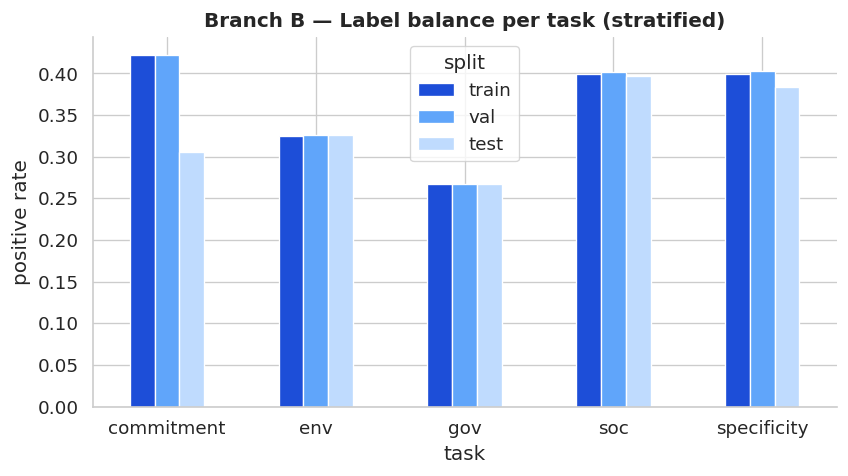

In [3]:
rows = [{"task": t, "split": sp, "pos_rate": gold[t][sp]["label"].mean()}
        for t in TASKS for sp in SPLITS]
piv = pd.DataFrame(rows).pivot(index="task", columns="split", values="pos_rate")[SPLITS]
fig, ax = plt.subplots(figsize=(8, 4))
piv.plot.bar(ax=ax, color=["#1d4ed8", "#60a5fa", "#bfdbfe"])
ax.set_ylabel("positive rate"); ax.set_title("Branch B — Label balance per task (stratified)")
ax.legend(title="split"); plt.xticks(rotation=0)
savefig("gold_label_balance"); plt.show()

## 2. Topic-set overlap E/S/G
The three topic datasets are largely disjoint -> train 3 separate binary classifiers, not one multi-label model.

unique texts: E=1960 S=1988 G=1972 | shared by all 3=1011 | union=3609


saved -> figures/phase01/gold_topic_overlap.png (+pdf)


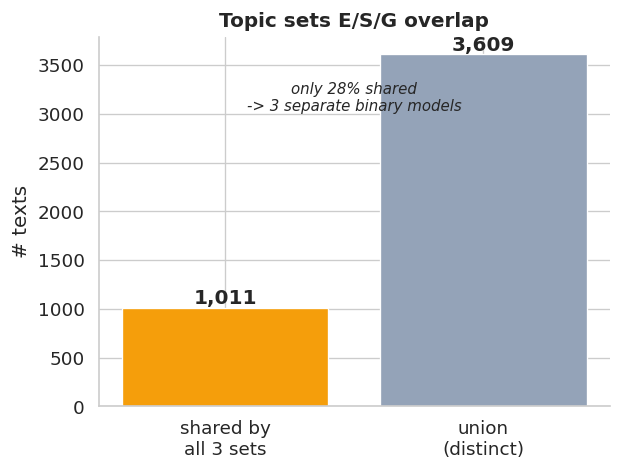

In [4]:
src = ROOT / "data/en_gold/translate"
e = set(pd.read_csv(src / "environmental_2k.csv")["text"])
s = set(pd.read_csv(src / "social_2k.csv")["text"])
g = set(pd.read_csv(src / "governance_2k.csv")["text"])
all3, union = len(e & s & g), len(e | s | g)
print(f"unique texts: E={len(e)} S={len(s)} G={len(g)} | shared by all 3={all3} | union={union}")
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["shared by\nall 3 sets", "union\n(distinct)"], [all3, union], color=["#f59e0b", "#94a3b8"])
ax.set_ylabel("# texts"); ax.set_title("Topic sets E/S/G overlap")
for i, v in enumerate([all3, union]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax.text(0.5, 0.80, f"only {100*all3/union:.0f}% shared\n-> 3 separate binary models",
        transform=ax.transAxes, ha="center", fontsize=9, style="italic")
savefig("gold_topic_overlap"); plt.show()

## 3. Commitment x Specificity -> CTI structure (key figure)
Commitment (the *talk*) gates the index; specificity (proxy for *walk*) is the numerator. `CTI = non-specific commitments / commitments`.

saved -> figures/phase01/gold_cti_crosstab.png (+pdf)


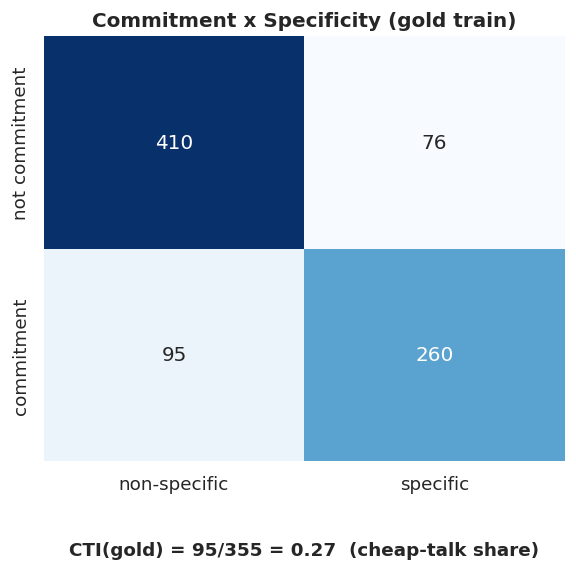

In [5]:
c = gold["commitment"]["train"]["label"].reset_index(drop=True)
sp = gold["specificity"]["train"]["label"].reset_index(drop=True)
assert gold["commitment"]["train"]["sentence"].reset_index(drop=True).equals(
       gold["specificity"]["train"]["sentence"].reset_index(drop=True)), "commit/spec not aligned!"
ct = pd.crosstab(c, sp)
ct.index = ["not commitment", "commitment"]; ct.columns = ["non-specific", "specific"]
fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Commitment x Specificity (gold train)")
n_commit = int(ct.loc["commitment"].sum())
nonspec = int(ct.loc["commitment", "non-specific"])
ax.text(0.5, -0.22, f"CTI(gold) = {nonspec}/{n_commit} = {nonspec/n_commit:.2f}  (cheap-talk share)",
        transform=ax.transAxes, ha="center", fontsize=11, fontweight="bold")
savefig("gold_cti_crosstab"); plt.show()

## 4. Split integrity: leakage & commitment-specificity alignment

In [6]:
print("train-test leakage (shared sentences, expect 0):")
for t in TASKS:
    tr, te = set(gold[t]["train"]["sentence"]), set(gold[t]["test"]["sentence"])
    print(f"  {t:12} {len(tr & te)}")
print("\ncommitment == specificity alignment per split (expect True):")
for sp_name in SPLITS:
    a = gold["commitment"][sp_name]["sentence"].reset_index(drop=True)
    b = gold["specificity"][sp_name]["sentence"].reset_index(drop=True)
    print(f"  {sp_name:6} {a.equals(b)}")

train-test leakage (shared sentences, expect 0):
  env          0
  soc          0
  gov          0
  commitment   0
  specificity  0

commitment == specificity alignment per split (expect True):
  train  True
  val    True
  test   True


## 5. Translation samples (EN source -> VN)

In [7]:
en = pd.read_csv(ROOT / "data/en_gold/topic/environmental_2k.csv")["text"]
vn = pd.read_csv(ROOT / "data/en_gold/translate/environmental_2k.csv")["text"]
for i in range(3):
    print("EN:", str(en.iloc[i])[:95])
    print("VN:", str(vn.iloc[i])[:95])
    print()

EN: The balance included in-kind donations prepared in accordance with B4SI guidelines.
VN: Tổng giá trị bao gồm các khoản đóng góp bằng tiền mặt và hàng hóa đã được chuẩn bị theo hướng d

EN: Internal controls and risk management The Board, through the Audit Committee, is responsible fo
VN: Kiểm soát nội bộ và quản lý rủi ro: Hội đồng quản trị, thông qua Ủy ban Kiểm toán, chịu trách n

EN: This analysis does not take into account the energy mix related to the electricity consumption 
VN: Phân tích này không xem xét sự kết hợp năng lượng liên quan đến mức tiêu thụ điện của các công 

